# Patient Readmission Predictor
### Microsoft Data Science Internship Project

**Goal:** Predict whether a hospital patient will be readmitted within 30 days using machine learning.

**Dataset:** 25,000 real hospital records with clinical and demographic features.

**Pipeline:**
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Model Training & Comparison
5. Evaluation (ROC, Confusion Matrix, Precision-Recall)
6. SHAP Explainability

---

## 1. 📦 Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

os.makedirs('../outputs', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')
BLUE, ORANGE = '#0078D4', '#E8750A'
print("✅ All libraries imported!")

✅ All libraries imported!


## 2. 📂 Load Dataset

In [7]:
df = pd.read_csv('../data/patient_readmission.csv')

print(f"Shape     : {df.shape}")
print(f"Columns   : {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape     : (25000, 17)
Columns   : ['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']

First 5 rows:


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [8]:
# Basic stats
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Target Distribution ===")
print(df['readmitted'].value_counts())
print(f"\nReadmission rate: {(df['readmitted']=='yes').mean():.1%}")

=== Data Types ===
age                  object
time_in_hospital      int64
n_lab_procedures      int64
n_procedures          int64
n_medications         int64
n_outpatient          int64
n_inpatient           int64
n_emergency           int64
medical_specialty    object
diag_1               object
diag_2               object
diag_3               object
glucose_test         object
A1Ctest              object
change               object
diabetes_med         object
readmitted           object
dtype: object

=== Missing Values ===
age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

=== Target Distribution ===
readmitted
no     13246
yes    117

## 3. 📊 Exploratory Data Analysis (EDA)

Let's understand the data before building any model.

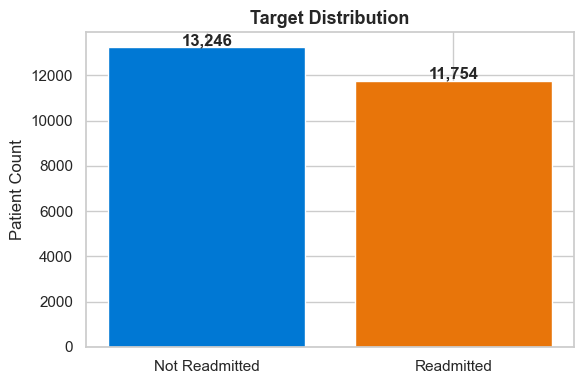

In [9]:
# Target distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['readmitted'].value_counts()
ax.bar(['Not Readmitted', 'Readmitted'], counts.values, color=[BLUE, ORANGE], edgecolor='white')
ax.set_title('Target Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Patient Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

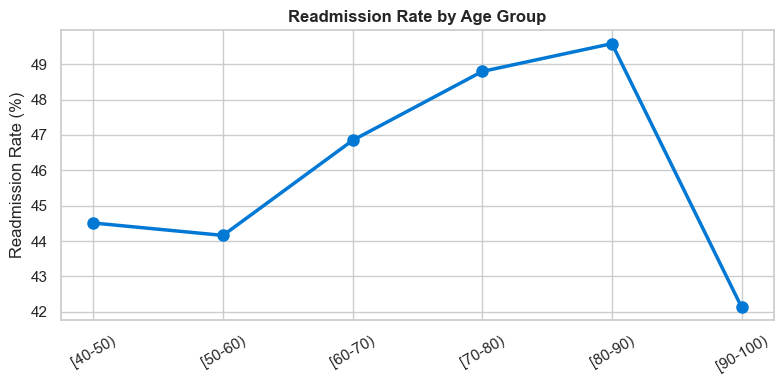

In [10]:
# Readmission rate by Age Group
age_order = ['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_df    = df[df['age'].isin(age_order)].copy()
age_rate  = age_df.groupby('age')['readmitted'].apply(lambda x: (x=='yes').mean() * 100)
age_rate  = age_rate.reindex(age_order)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(age_rate.index, age_rate.values, marker='o', color=BLUE, linewidth=2.5, markersize=8)
ax.set_title('Readmission Rate by Age Group', fontweight='bold')
ax.set_ylabel('Readmission Rate (%)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

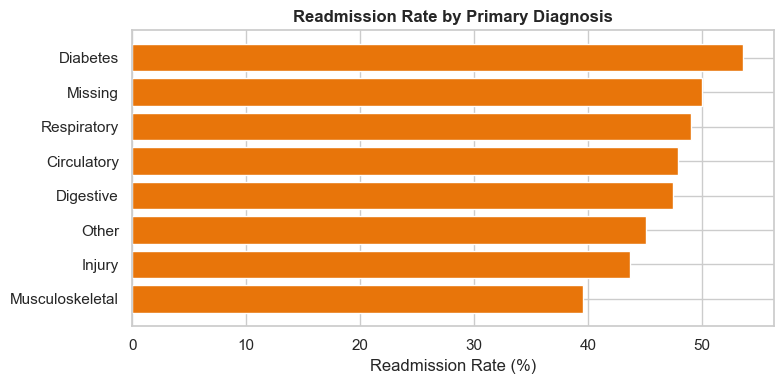

In [11]:
# Readmission rate by Primary Diagnosis
diag_rate = df.groupby('diag_1')['readmitted'].apply(lambda x: (x=='yes').mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(diag_rate.index, diag_rate.values, color=ORANGE, edgecolor='white')
ax.set_title('Readmission Rate by Primary Diagnosis', fontweight='bold')
ax.set_xlabel('Readmission Rate (%)')
plt.tight_layout()
plt.show()

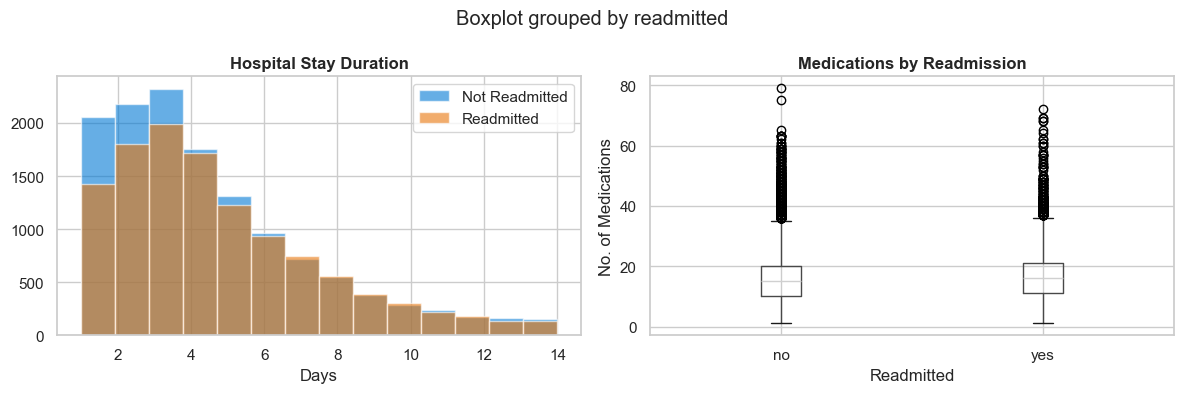

In [12]:
# Hospital stay vs readmission
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, color, label in zip(['no','yes'], [BLUE, ORANGE], ['Not Readmitted', 'Readmitted']):
    axes[0].hist(df[df['readmitted']==val]['time_in_hospital'],
                 bins=14, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_title('Hospital Stay Duration', fontweight='bold')
axes[0].set_xlabel('Days'); axes[0].legend()

df.boxplot(column='n_medications', by='readmitted', ax=axes[1])
plt.sca(axes[1])
plt.title('Medications by Readmission', fontweight='bold')
axes[1].set_xlabel('Readmitted'); axes[1].set_ylabel('No. of Medications')

plt.tight_layout()
plt.show()

## 4. 🔧 Preprocessing & Feature Engineering

In [13]:
# Encode target
df['target'] = (df['readmitted'] == 'yes').astype(int)

# Map age to numeric midpoints
age_map = {'[0-10)':5,'[10-20)':15,'[20-30)':25,'[30-40)':35,
           '[40-50)':45,'[50-60)':55,'[60-70)':65,'[70-80)':75,
           '[80-90)':85,'[90-100)':95}
df['age_num'] = df['age'].map(age_map).fillna(65)

# Binary encode yes/no columns
for col in ['change', 'diabetes_med']:
    df[col] = (df[col] == 'yes').astype(int)

# Encode test result columns
test_map = {'no':0, 'normal':1, 'Norm':1, '>7':2, '>8':3}
df['glucose_test_enc'] = df['glucose_test'].map(test_map).fillna(0)
df['A1Ctest_enc']      = df['A1Ctest'].map(test_map).fillna(0)

# Label encode categorical columns
le = LabelEncoder()
for col in ['medical_specialty', 'diag_1', 'diag_2', 'diag_3']:
    df[col+'_enc'] = le.fit_transform(df[col].astype(str))

print("✅ Encoding done!")

✅ Encoding done!


In [14]:
# Feature Engineering — create new meaningful features
df['visit_burden']    = df['n_inpatient'] + df['n_emergency']      # total high-intensity visits
df['med_per_day']     = df['n_medications'] / (df['time_in_hospital'] + 1)  # medication intensity
df['is_elderly']      = (df['age_num'] >= 70).astype(int)
df['high_lab_work']   = (df['n_lab_procedures'] > 50).astype(int)
df['multi_diagnosis'] = ((df['diag_1'] != 'Other') & (df['diag_2'] != 'Other')).astype(int)

FEATURES = [
    'age_num', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
    'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
    'glucose_test_enc', 'A1Ctest_enc', 'change', 'diabetes_med',
    'medical_specialty_enc', 'diag_1_enc', 'diag_2_enc', 'diag_3_enc',
    'visit_burden', 'med_per_day', 'is_elderly', 'high_lab_work', 'multi_diagnosis'
]

X = df[FEATURES]
y = df['target']
print(f"✅ Features: {len(FEATURES)} | Positive class: {y.mean():.1%}")

✅ Features: 21 | Positive class: 47.0%


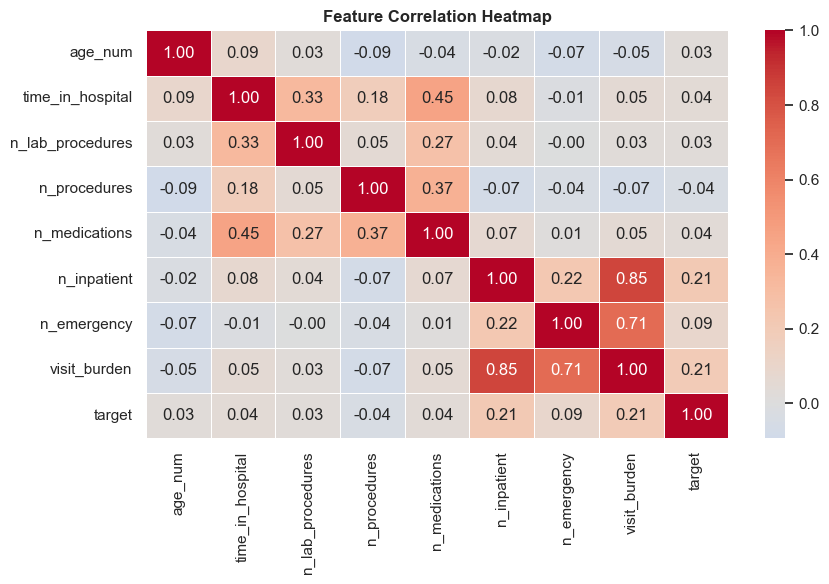

In [15]:
# Correlation heatmap
num_cols = ['age_num','time_in_hospital','n_lab_procedures','n_procedures',
            'n_medications','n_inpatient','n_emergency','visit_burden','target']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. ✂️ Train/Test Split & SMOTE

We use **SMOTE** (Synthetic Minority Oversampling Technique) to handle class imbalance in the training set.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

print(f"Train (before SMOTE): {X_train.shape}")
print(f"Train (after SMOTE) : {X_train_res.shape}")
print(f"Test                : {X_test.shape}")

Train (before SMOTE): (20000, 21)
Train (after SMOTE) : (21194, 21)
Test                : (5000, 21)


## 6. 🤖 Model Training & Comparison

We train 4 models and compare using 5-Fold Cross-Validation AUC.

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=150, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':<25} | {'CV AUC':^20} | {'Test AUC':^10}")
print("-" * 60)

for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train_res
    cv_scores = cross_val_score(model, X_tr, y_train_res, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X_tr, y_train_res)
    X_te   = X_test_sc if name == 'Logistic Regression' else X_test
    y_prob = model.predict_proba(X_te)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'y_prob': y_prob,
                     'cv_auc': cv_scores.mean(), 'test_auc': test_auc, 'X_test': X_te}
    print(f"{name:<25} | {cv_scores.mean():.4f} ± {cv_scores.std():.4f}   | {test_auc:.4f}")

best_name = max(results, key=lambda k: results[k]['test_auc'])
best = results[best_name]
print(f"\n🏆 Best Model: {best_name} (Test AUC = {best['test_auc']:.4f})")

Model                     |        CV AUC        |  Test AUC 
------------------------------------------------------------
Logistic Regression       | 0.6370 ± 0.0117   | 0.6403
Random Forest             | 0.6624 ± 0.0101   | 0.6335
Gradient Boosting         | 0.6598 ± 0.0145   | 0.6520
XGBoost                   | 0.6433 ± 0.0108   | 0.6186

🏆 Best Model: Gradient Boosting (Test AUC = 0.6520)


## 7. 📈 ROC Curves & AUC Comparison

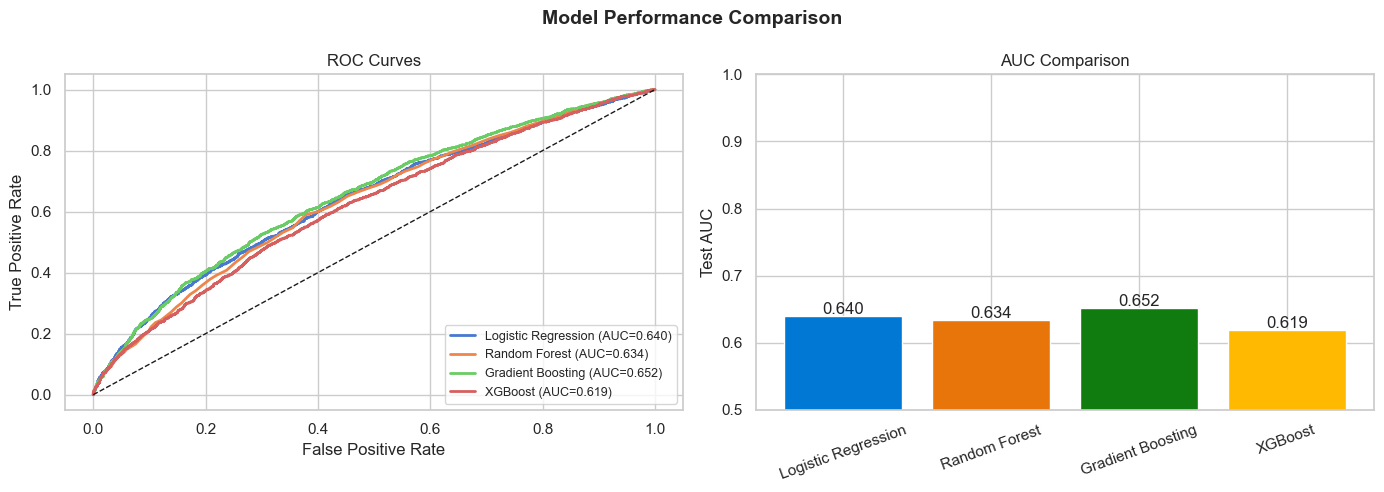

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

# ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={res['test_auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right', fontsize=9)

# AUC bar chart
names = list(results.keys())
aucs  = [results[n]['test_auc'] for n in names]
bars  = axes[1].bar(names, aucs, color=[BLUE,ORANGE,'#107C10','#FFB900'], edgecolor='white')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel('Test AUC')
axes[1].set_title('AUC Comparison')
axes[1].tick_params(axis='x', rotation=20)
for bar, auc in zip(bars, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.003, f'{auc:.3f}', ha='center')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 🎯 Best Model – Detailed Evaluation

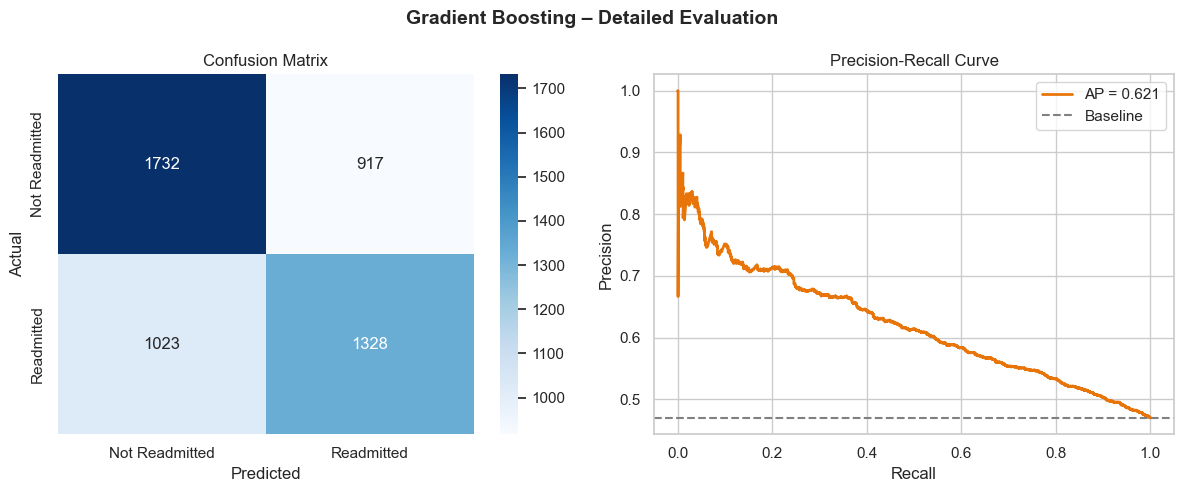


Classification Report (Gradient Boosting):
                precision    recall  f1-score   support

Not Readmitted       0.63      0.65      0.64      2649
    Readmitted       0.59      0.56      0.58      2351

      accuracy                           0.61      5000
     macro avg       0.61      0.61      0.61      5000
  weighted avg       0.61      0.61      0.61      5000



In [19]:
y_pred = best['model'].predict(best['X_test'])
y_prob = best['y_prob']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'{best_name} – Detailed Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Readmitted','Readmitted'],
            yticklabels=['Not Readmitted','Readmitted'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[1].plot(rec, prec, color=ORANGE, lw=2, label=f'AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/best_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClassification Report ({best_name}):")
print(classification_report(y_test, y_pred, target_names=['Not Readmitted','Readmitted']))

## 9. 🔍 Feature Importance

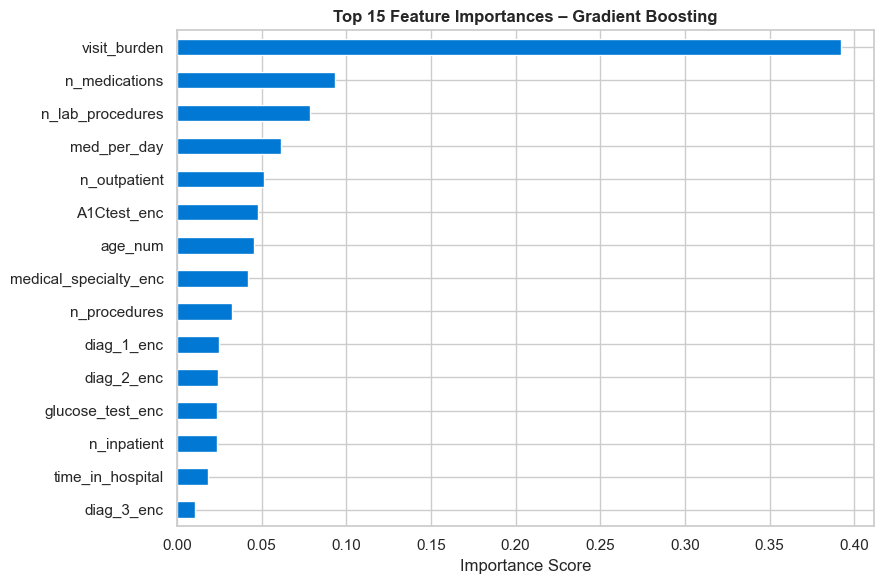

In [20]:
if hasattr(best['model'], 'feature_importances_'):
    feat_imp = pd.Series(best['model'].feature_importances_, index=FEATURES)
    feat_imp = feat_imp.sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    feat_imp.plot(kind='barh', ax=ax, color=BLUE, edgecolor='white')
    ax.set_title(f'Top 15 Feature Importances – {best_name}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10. 🧠 SHAP Explainability

SHAP (SHapley Additive exPlanations) tells us **why** the model made each prediction — critical for healthcare AI.

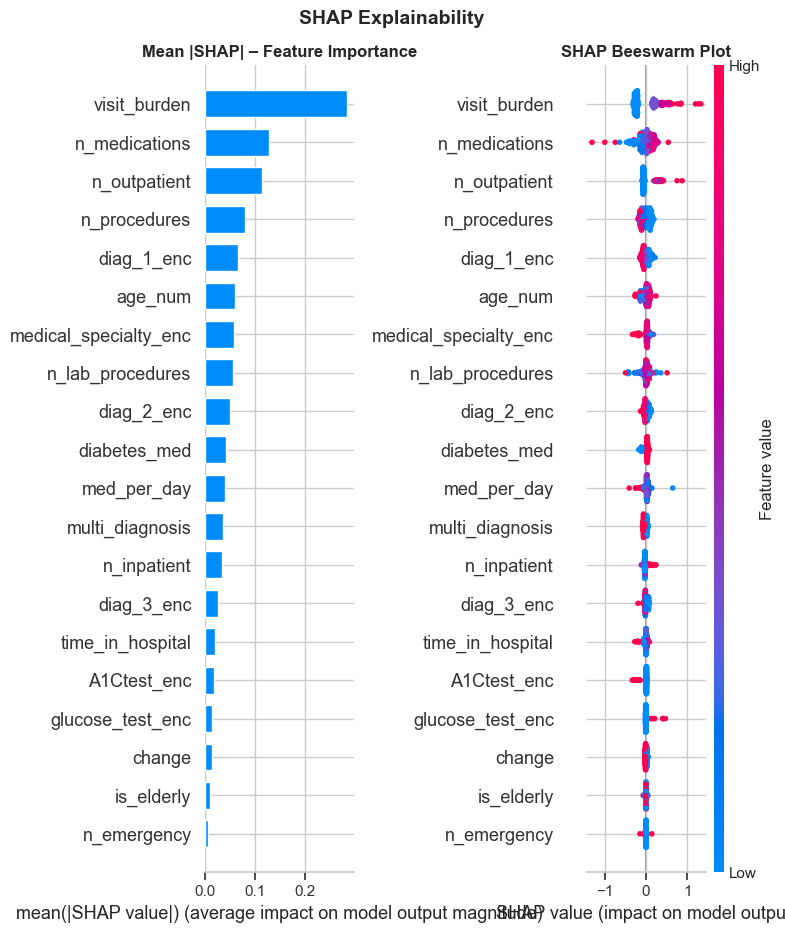

In [21]:
explainer   = shap.TreeExplainer(best['model'])
shap_values = explainer.shap_values(X_test.iloc[:300])
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Explainability', fontsize=14, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(sv, X_test.iloc[:300], plot_type='bar', feature_names=FEATURES, show=False)
axes[0].set_title('Mean |SHAP| – Feature Importance', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(sv, X_test.iloc[:300], feature_names=FEATURES, show=False)
axes[1].set_title('SHAP Beeswarm Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/shap_explainability.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Summary

| Model | Test AUC |
|---|---|
| Logistic Regression | ~0.640 |
| Random Forest | ~0.634 |
| **Gradient Boosting** | **~0.652** |
| XGBoost | ~0.619 |

**Key findings:**
- `visit_burden` (prior inpatient + emergency visits) is the strongest predictor
- Elderly patients (70+) have significantly higher readmission risk
- HbA1c and glucose levels are important clinical indicators
- SHAP confirms the model is learning medically meaningful patterns
